<a href="https://colab.research.google.com/github/meriemsakhri/spam-ham-email-classifier/blob/main/Projet_FULL_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ All imports done.

📦 Dataset loaded.
   Shape       : (5171, 3)
   Columns     : ['label', 'text', 'class']
   Missing vals: 0

   Class distribution:
label
ham     3672
spam    1499


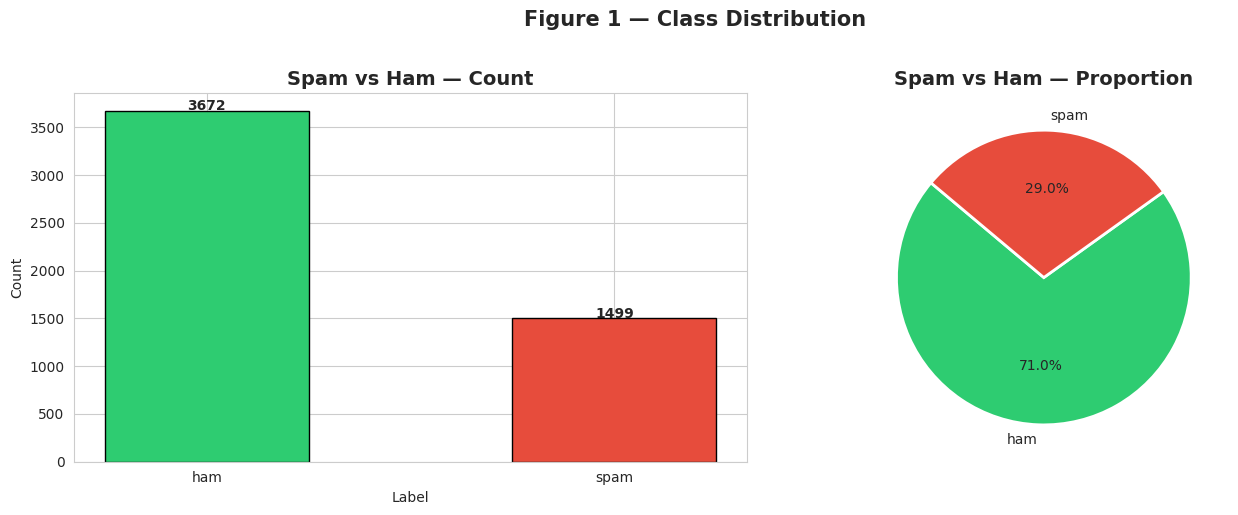

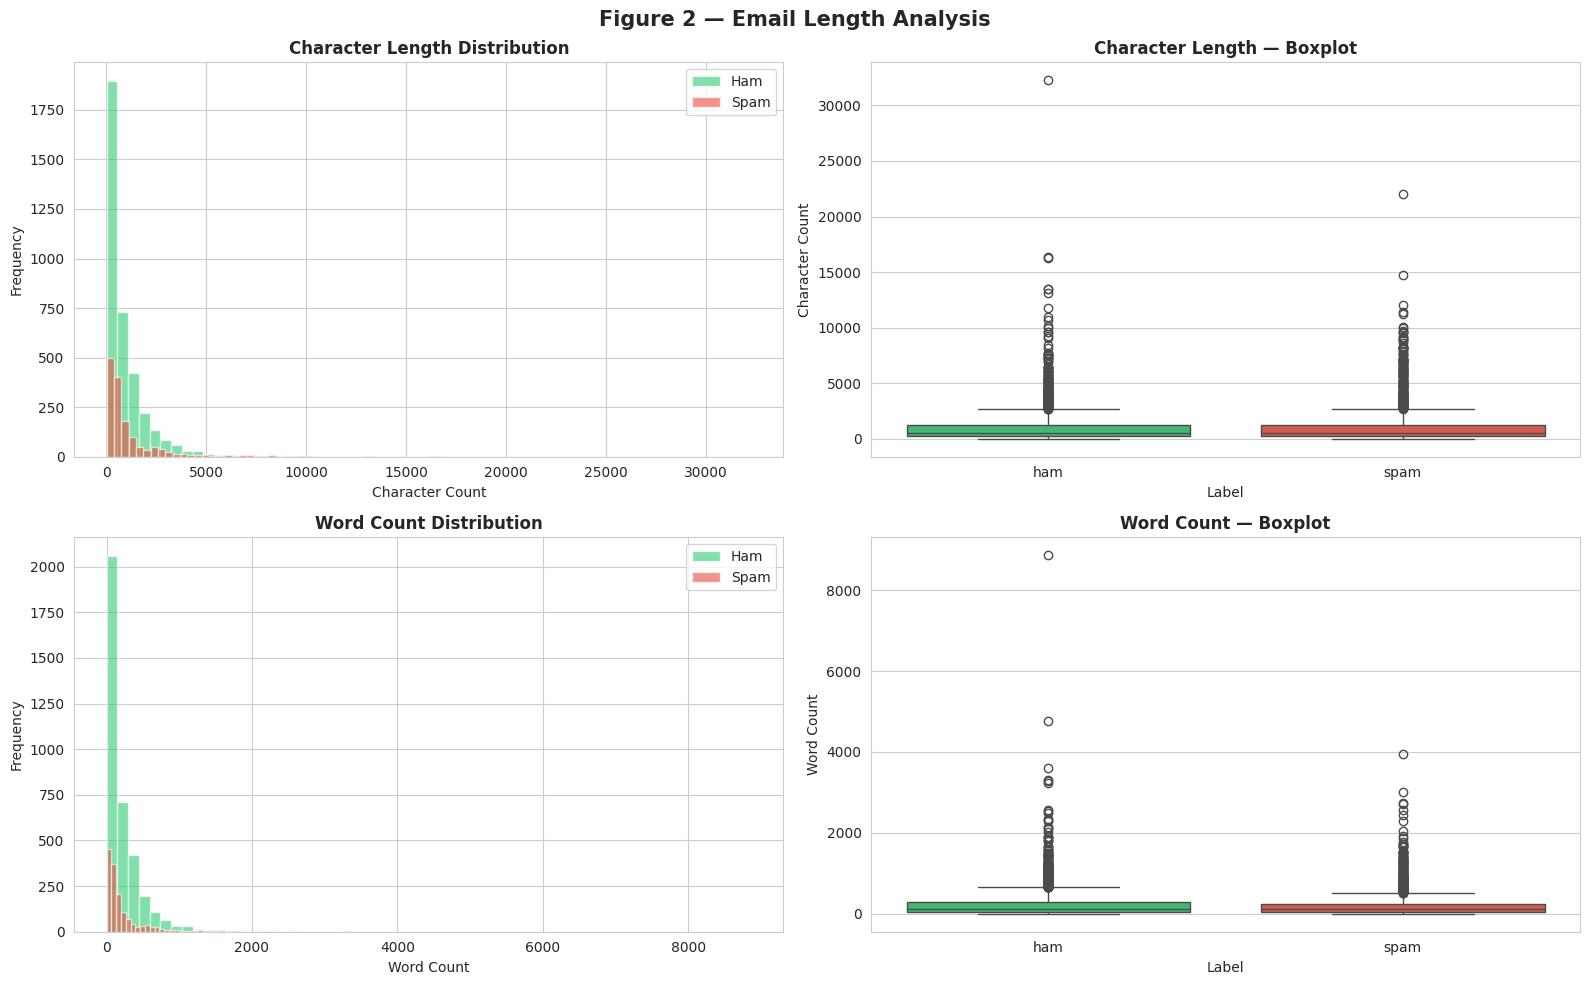


   Avg char length  — Ham : 977
   Avg char length  — Spam: 1223
   Avg word count   — Ham : 225
   Avg word count   — Spam: 234


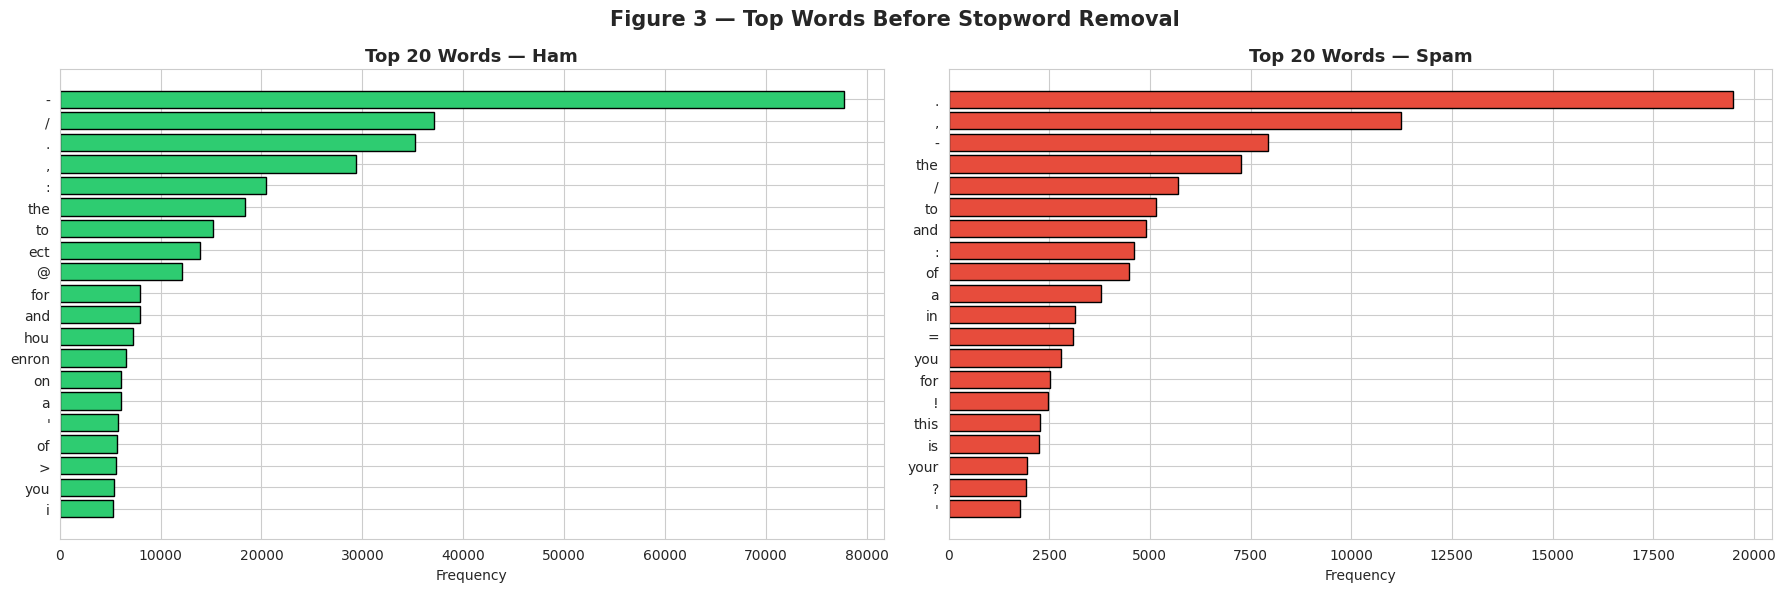


⚙️  Preprocessing text (removing stopwords)...
✅ Stopword removal done.


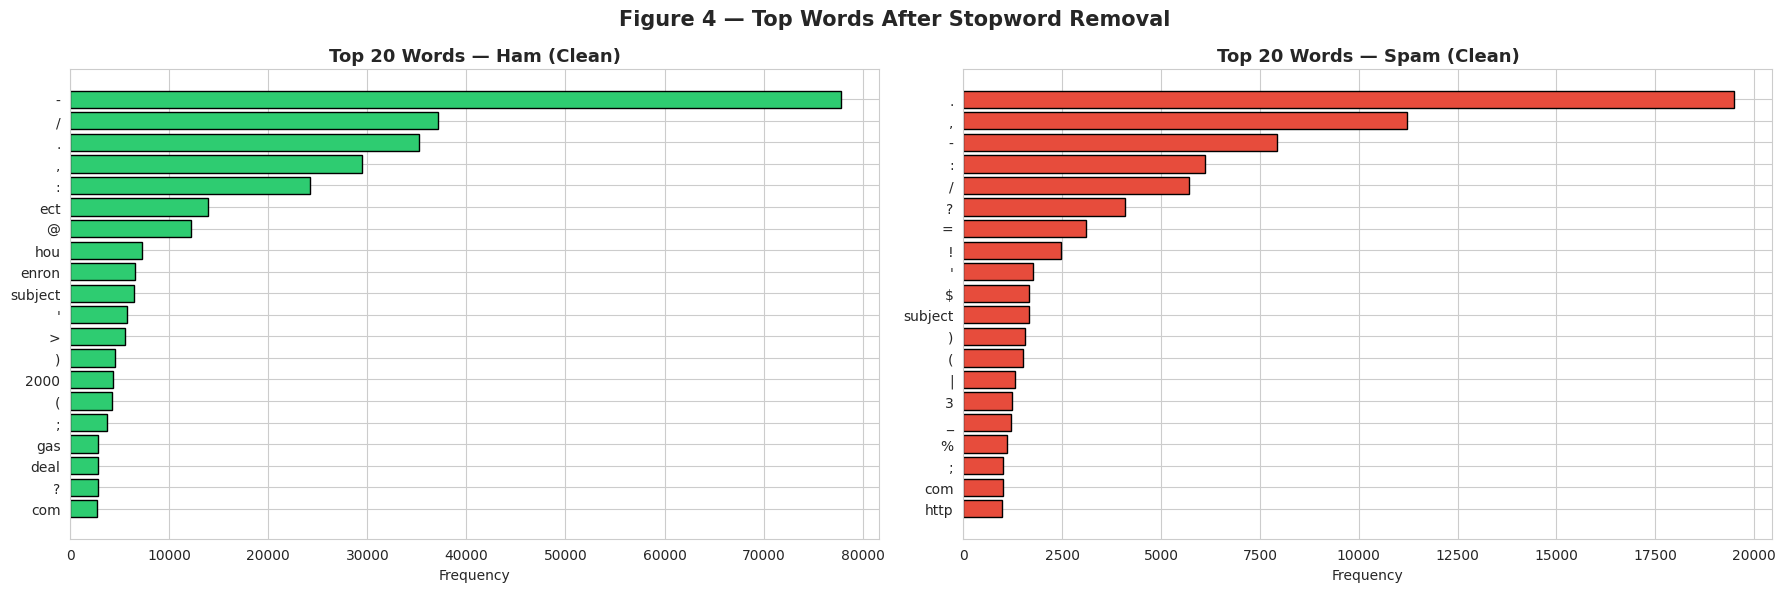


   X shape: (5171,)
   y shape: (5171,)

✂️  Splitting data → Train / Validation / Test
   Train size      : 3621 (70.0%)
   Validation size : 774  (15.0%)
   Test size       : 776  (15.0%)


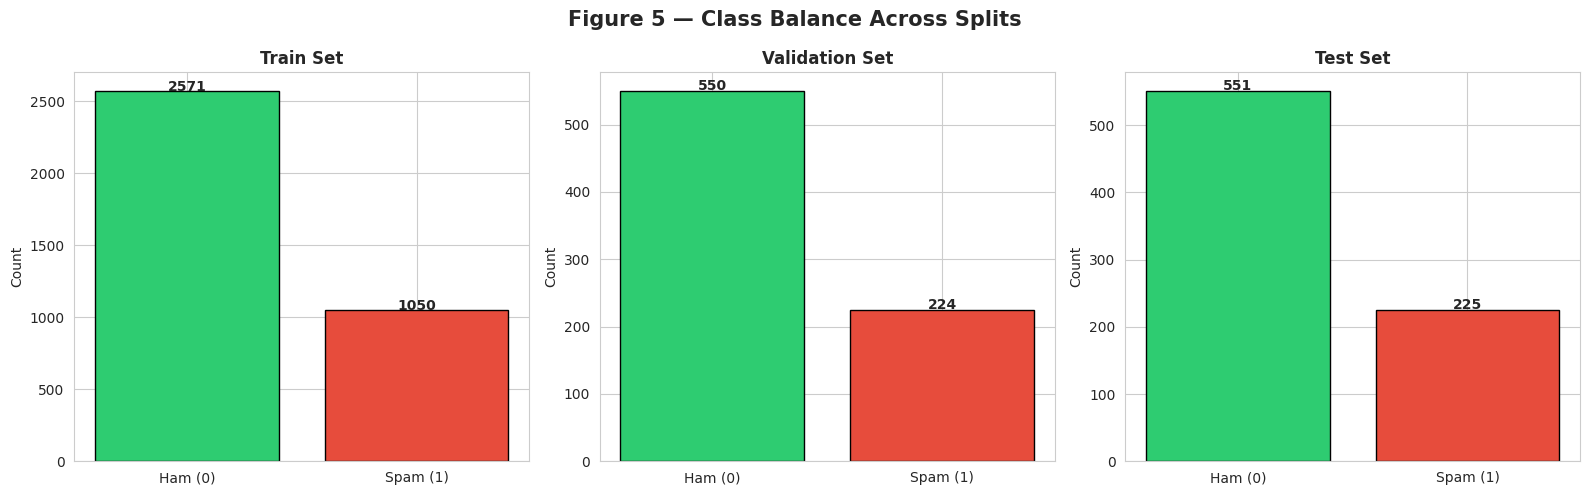


🔢 Vectorizing text with TF-IDF...
   Train matrix shape : (3621, 20000)
   Val   matrix shape : (774, 20000)
   Test  matrix shape : (776, 20000)

📊 Plotting top-50 token correlation heatmap...


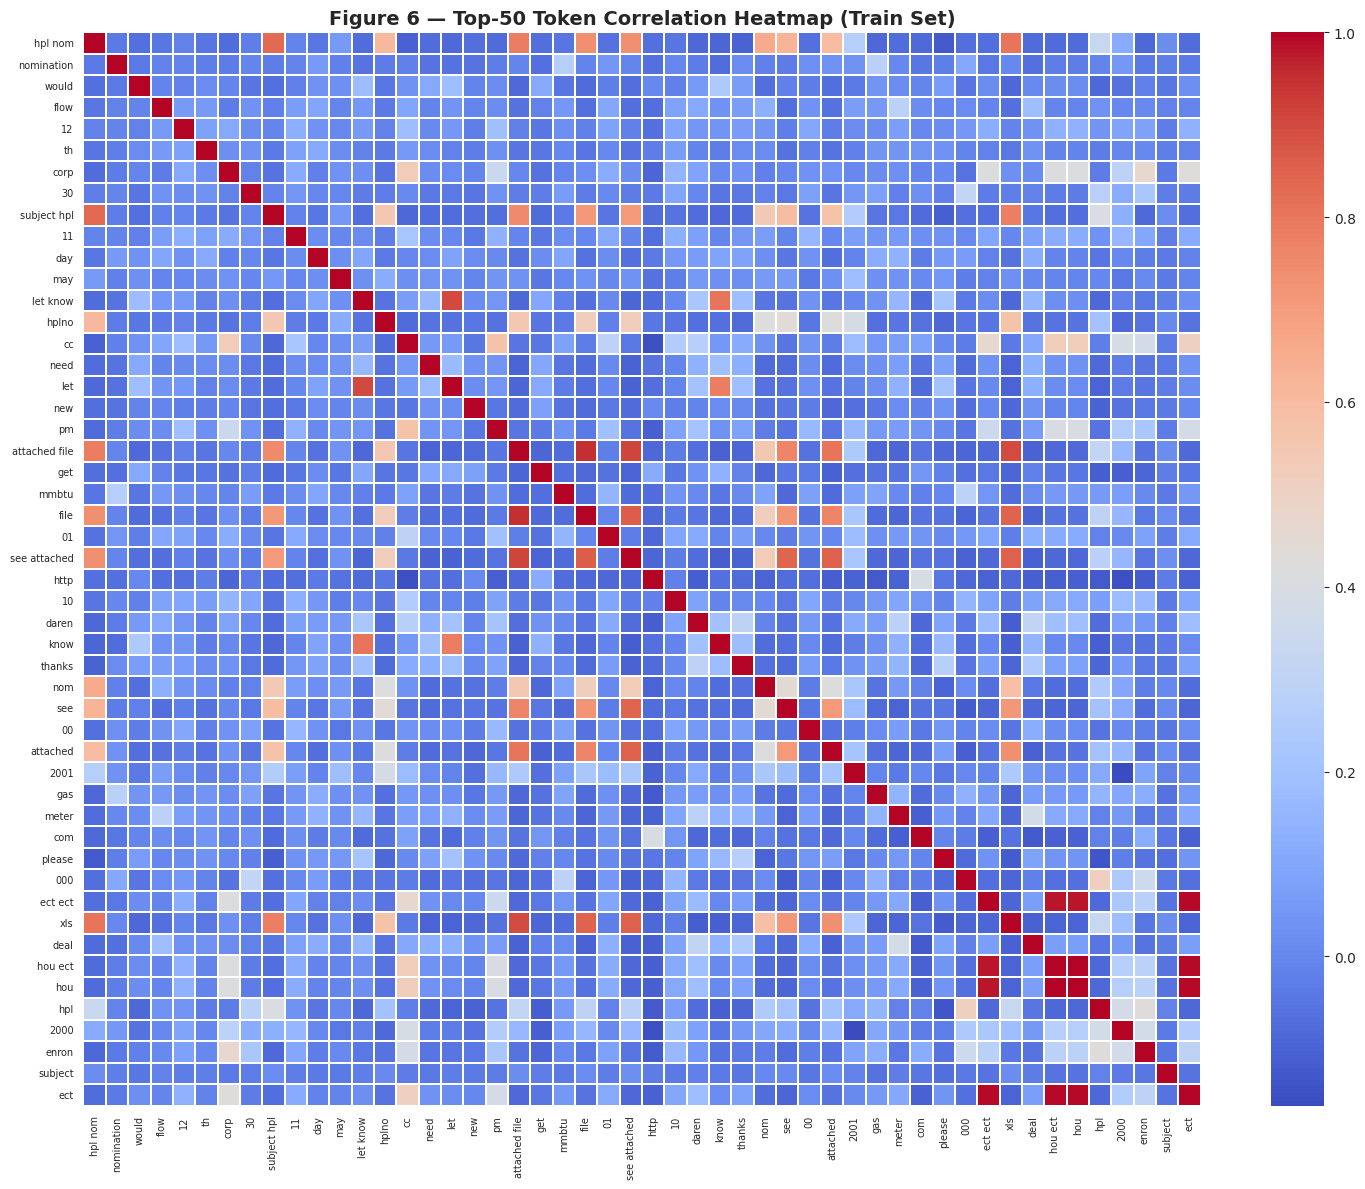


🔍 Tuning Logistic Regression via GridSearchCV...
   Best params : {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
   Best CV acc : 0.9892

── Logistic Regression │ Validation Set ──
   Accuracy : 0.9897
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       550
        Spam       0.98      0.99      0.98       224

    accuracy                           0.99       774
   macro avg       0.99      0.99      0.99       774
weighted avg       0.99      0.99      0.99       774



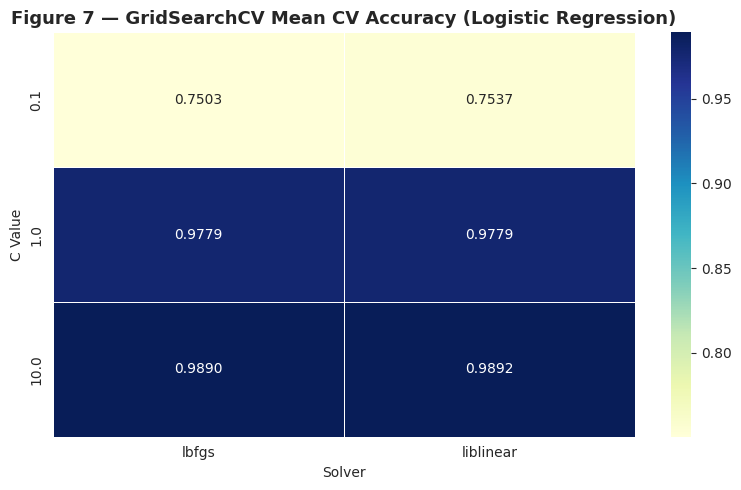


🌲 Training Random Forest...
✅ Random Forest trained.

── Random Forest │ Validation Set ──
   Accuracy : 0.9884
              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99       550
        Spam       0.97      0.99      0.98       224

    accuracy                           0.99       774
   macro avg       0.98      0.99      0.99       774
weighted avg       0.99      0.99      0.99       774



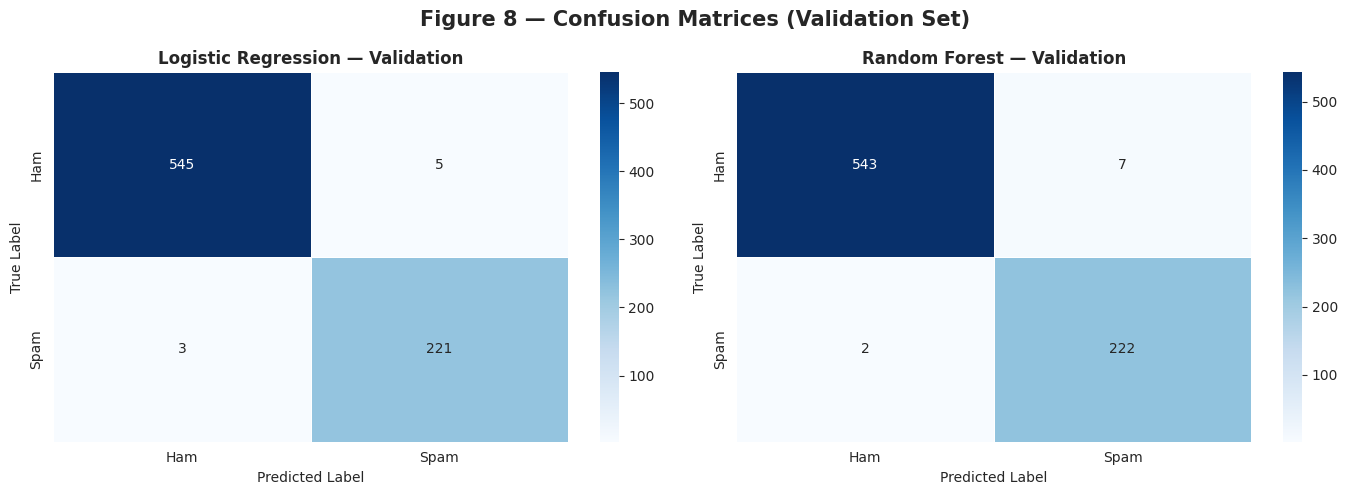

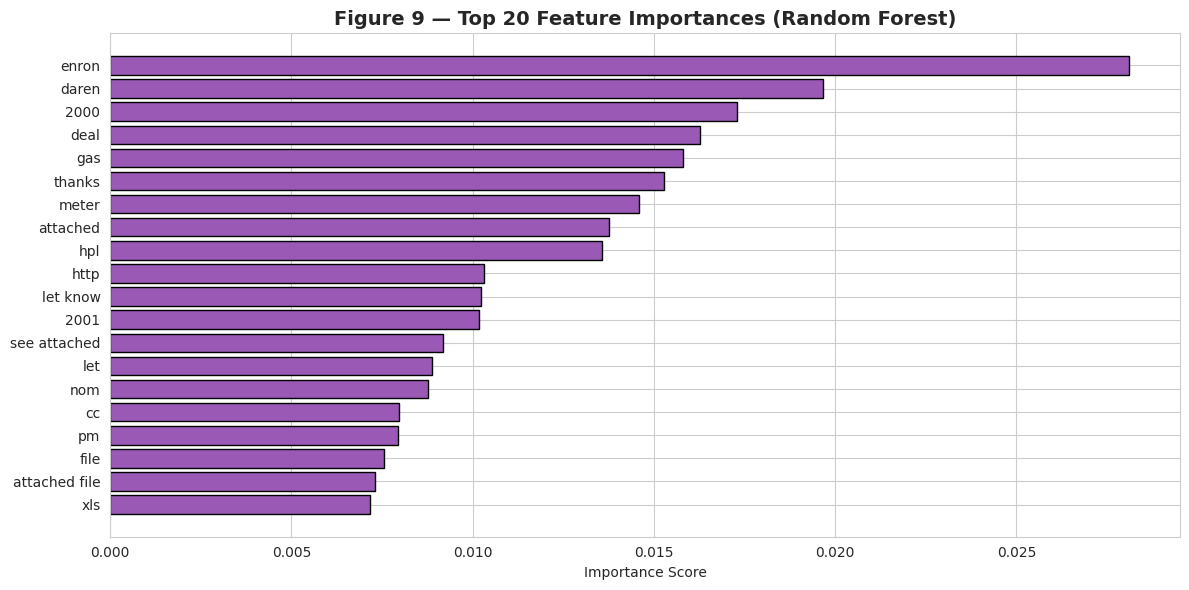

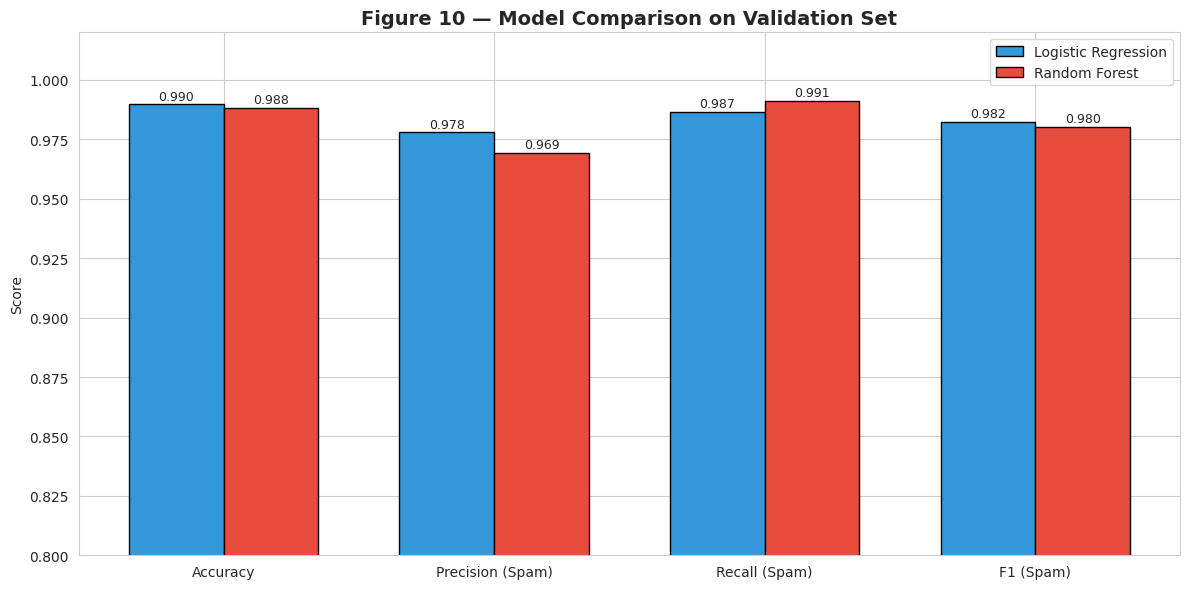


🔒 FINAL EVALUATION ON TEST SET (unsealed once)

── Logistic Regression │ Test Set ──
   Accuracy : 0.9884
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       551
        Spam       0.99      0.97      0.98       225

    accuracy                           0.99       776
   macro avg       0.99      0.98      0.99       776
weighted avg       0.99      0.99      0.99       776


── Random Forest │ Test Set ──
   Accuracy : 0.9807
              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99       551
        Spam       0.94      0.99      0.97       225

    accuracy                           0.98       776
   macro avg       0.97      0.98      0.98       776
weighted avg       0.98      0.98      0.98       776



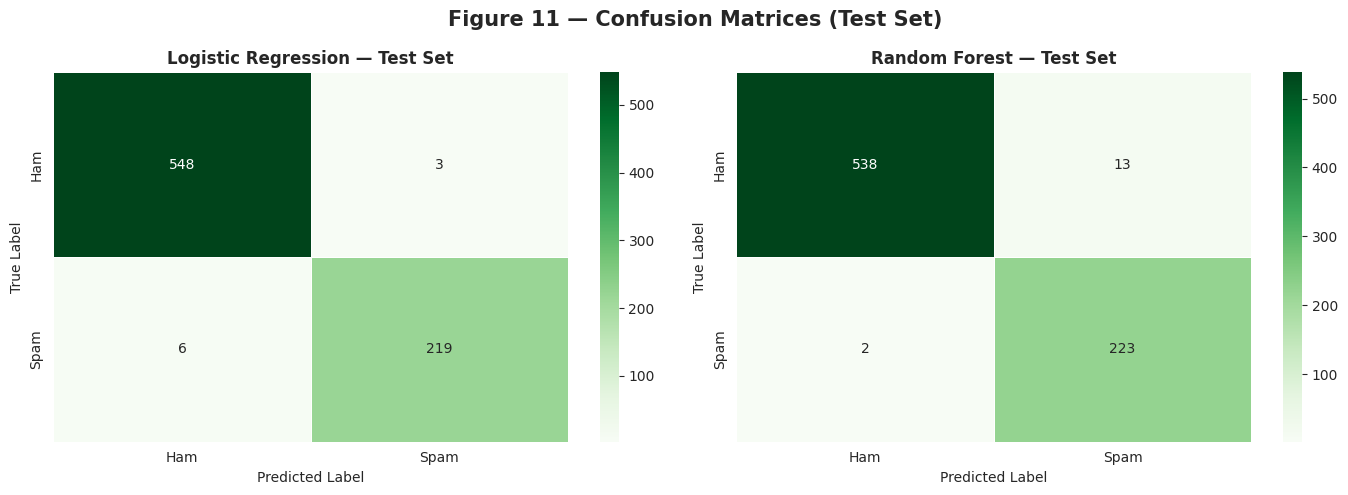

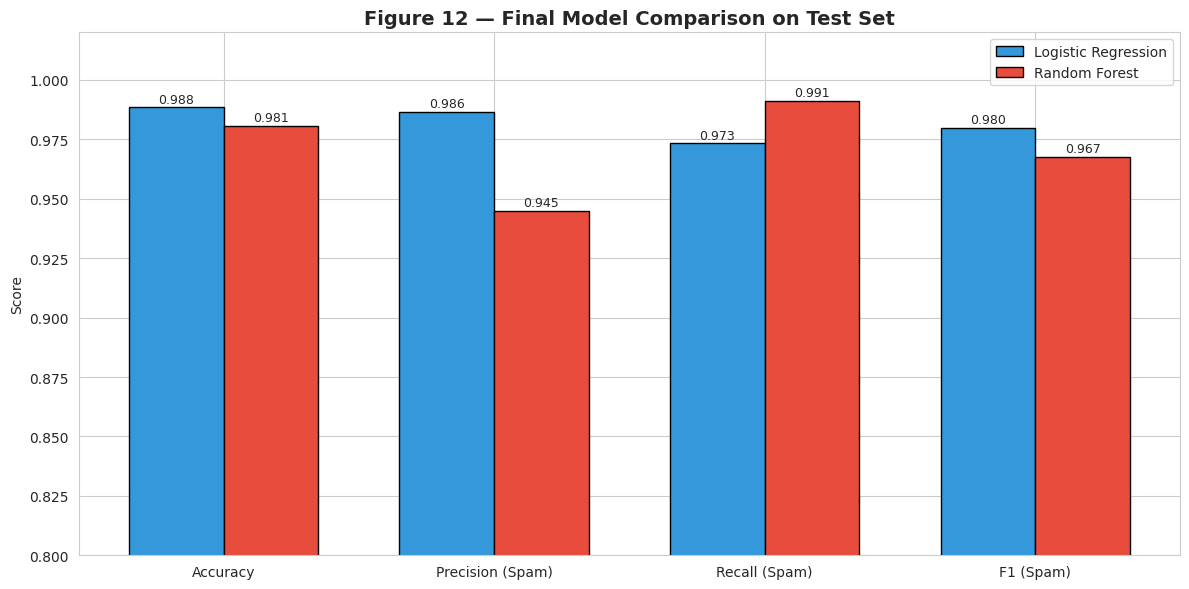


✅ Pipeline complete.


In [ ]:
# -*- coding: utf-8 -*-

# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import GridSearchCV
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style('whitegrid')
PALETTE = {'Ham': '#2ecc71', 'Spam': '#e74c3c'}

print("=" * 60)
print("✅ All imports done.")
print("=" * 60)

# ── Load & Clean Data ─────────────────────────────────────────────────────────
df = pd.read_csv('spam_ham_dataset.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.columns = ['label', 'text', 'class']

print(f"\n📦 Dataset loaded.")
print(f"   Shape       : {df.shape}")
print(f"   Columns     : {list(df.columns)}")
print(f"   Missing vals: {df.isna().sum().sum()}")
print(f"\n   Class distribution:\n{df['label'].value_counts().to_string()}")

# ── Figure 1: Class Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Spam vs Ham — Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Spam vs Ham — Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Figure 1 — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Figure 2: Email Length Analysis ───────────────────────────────────────────
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
    subset = df[df['label'] == label]['text_length']
    axes[0][0].hist(subset, bins=60, alpha=0.6, color=color, label=label.capitalize(), edgecolor='white')
axes[0][0].set_title('Character Length Distribution', fontweight='bold')
axes[0][0].set_xlabel('Character Count')
axes[0][0].set_ylabel('Frequency')
axes[0][0].legend()

sns.boxplot(data=df, x='label', y='text_length', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[0][1])
axes[0][1].set_title('Character Length — Boxplot', fontweight='bold')
axes[0][1].set_xlabel('Label')
axes[0][1].set_ylabel('Character Count')

for label, color in [('ham', '#2ecc71'), ('spam', '#e74c3c')]:
    subset = df[df['label'] == label]['word_count']
    axes[1][0].hist(subset, bins=60, alpha=0.6, color=color, label=label.capitalize(), edgecolor='white')
axes[1][0].set_title('Word Count Distribution', fontweight='bold')
axes[1][0].set_xlabel('Word Count')
axes[1][0].set_ylabel('Frequency')
axes[1][0].legend()

sns.boxplot(data=df, x='label', y='word_count', palette={'ham': '#2ecc71', 'spam': '#e74c3c'}, ax=axes[1][1])
axes[1][1].set_title('Word Count — Boxplot', fontweight='bold')
axes[1][1].set_xlabel('Label')
axes[1][1].set_ylabel('Word Count')

plt.suptitle('Figure 2 — Email Length Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n   Avg char length  — Ham : {df[df['label']=='ham']['text_length'].mean():.0f}")
print(f"   Avg char length  — Spam: {df[df['label']=='spam']['text_length'].mean():.0f}")
print(f"   Avg word count   — Ham : {df[df['label']=='ham']['word_count'].mean():.0f}")
print(f"   Avg word count   — Spam: {df[df['label']=='spam']['word_count'].mean():.0f}")

# ── Figure 3: Top Words Per Class (before stopword removal) ───────────────────
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).lower().split()
    return Counter(all_words).most_common(n)

ham_words  = get_top_words(df[df['label'] == 'ham']['text'])
spam_words = get_top_words(df[df['label'] == 'spam']['text'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

words, freqs = zip(*ham_words)
axes[0].barh(words[::-1], freqs[::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 20 Words — Ham', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

words, freqs = zip(*spam_words)
axes[1].barh(words[::-1], freqs[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 20 Words — Spam', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Figure 3 — Top Words Before Stopword Removal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Text Preprocessing ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("⚙️  Preprocessing text (removing stopwords)...")
print("=" * 60)

stop_words = set(stopwords.words('english'))
df['text'] = df['text'].apply(
    lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words])
)
print("✅ Stopword removal done.")

# ── Figure 4: Top Words After Stopword Removal ────────────────────────────────
ham_words_clean  = get_top_words(df[df['label'] == 'ham']['text'])
spam_words_clean = get_top_words(df[df['label'] == 'spam']['text'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

words, freqs = zip(*ham_words_clean)
axes[0].barh(words[::-1], freqs[::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 20 Words — Ham (Clean)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

words, freqs = zip(*spam_words_clean)
axes[1].barh(words[::-1], freqs[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 20 Words — Spam (Clean)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.suptitle('Figure 4 — Top Words After Stopword Removal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Features & Labels ─────────────────────────────────────────────────────────
X = df['text']
y = df['class']

print(f"\n   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

# ── 3-Way Split ───────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("✂️  Splitting data → Train / Validation / Test")
print("=" * 60)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=11, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=11, stratify=y_train_full
)

print(f"   Train size      : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation size : {len(X_val)}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test size       : {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")

# ── Figure 5: Split Class Balance Check ───────────────────────────────────────
split_labels = ['Train', 'Validation', 'Test']
split_ys     = [y_train, y_val, y_test]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name, y_split in zip(axes, split_labels, split_ys):
    counts = pd.Series(y_split).value_counts()
    ax.bar(['Ham (0)', 'Spam (1)'], [counts.get(0, 0), counts.get(1, 0)],
           color=['#2ecc71', '#e74c3c'], edgecolor='black')
    ax.set_title(f'{name} Set', fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        ax.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.suptitle('Figure 5 — Class Balance Across Splits', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── TF-IDF Vectorization ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("🔢 Vectorizing text with TF-IDF...")
print("=" * 60)

tfidf     = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
dtv_train = tfidf.fit_transform(X_train)
dtv_val   = tfidf.transform(X_val)
dtv_test  = tfidf.transform(X_test)

print(f"   Train matrix shape : {dtv_train.shape}")
print(f"   Val   matrix shape : {dtv_val.shape}")
print(f"   Test  matrix shape : {dtv_test.shape}")

# ── Figure 6: Top TF-IDF Token Correlation Heatmap ───────────────────────────
print("\n📊 Plotting top-50 token correlation heatmap...")

dtv_dense = dtv_train.toarray()
word_sums  = dtv_dense.sum(axis=0)
top_idx    = np.argsort(word_sums)[-50:]
dtv_top    = dtv_dense[:, top_idx]
corr       = np.corrcoef(dtv_top, rowvar=False)
top_words  = np.array(tfidf.get_feature_names_out())[top_idx]

plt.figure(figsize=(15, 12))
sns.heatmap(corr, xticklabels=top_words, yticklabels=top_words,
            cmap="coolwarm", annot=False, linewidths=0.3)
plt.title('Figure 6 — Top-50 Token Correlation Heatmap (Train Set)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# ── Logistic Regression + GridSearchCV ───────────────────────────────────────
print("\n" + "=" * 60)
print("🔍 Tuning Logistic Regression via GridSearchCV...")
print("=" * 60)

lr   = LogisticRegression(max_iter=1000)
grid = {"C": [0.1, 1.0, 10.0], "penalty": ["l2"], "solver": ["lbfgs", "liblinear"]}
logreg_cv = GridSearchCV(lr, grid, cv=4, n_jobs=-1, verbose=0)
logreg_cv.fit(dtv_train, y_train)

print(f"   Best params : {logreg_cv.best_params_}")
print(f"   Best CV acc : {logreg_cv.best_score_:.4f}")

lr_val_preds      = logreg_cv.predict(dtv_val)
lr_val_proba      = logreg_cv.predict_proba(dtv_val)[:, 1]

print(f"\n── Logistic Regression │ Validation Set ──")
print(f"   Accuracy : {accuracy_score(y_val, lr_val_preds):.4f}")
print(classification_report(y_val, lr_val_preds, target_names=['Ham', 'Spam']))

# ── Figure 8: GridSearchCV Heatmap ────────────────────────────────────────────
cv_results = pd.DataFrame(logreg_cv.cv_results_)
pivot = cv_results.pivot_table(index='param_C', columns='param_solver', values='mean_test_score')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5)
plt.title('Figure 7 — GridSearchCV Mean CV Accuracy (Logistic Regression)', fontsize=13, fontweight='bold')
plt.xlabel('Solver')
plt.ylabel('C Value')
plt.tight_layout()
plt.show()

# ── Random Forest ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("🌲 Training Random Forest...")
print("=" * 60)

clf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                              random_state=42, n_jobs=-1)
clf.fit(dtv_train, y_train)
print("✅ Random Forest trained.")

rf_val_preds = clf.predict(dtv_val)
rf_val_proba = clf.predict_proba(dtv_val)[:, 1]

print(f"\n── Random Forest │ Validation Set ──")
print(f"   Accuracy : {accuracy_score(y_val, rf_val_preds):.4f}")
print(classification_report(y_val, rf_val_preds, target_names=['Ham', 'Spam']))

# ── Figure 9: Confusion Matrices Side by Side (Validation) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [lr_val_preds, rf_val_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                linewidths=0.5)
    ax.set_title(f'{title} — Validation', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Figure 8 — Confusion Matrices (Validation Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 12: Feature Importance (Random Forest) ─────────────────────────────
importances  = clf.feature_importances_
top20_fi_idx = np.argsort(importances)[-20:]
top20_fi_words = np.array(tfidf.get_feature_names_out())[top20_fi_idx]
top20_fi_vals  = importances[top20_fi_idx]

plt.figure(figsize=(12, 6))
plt.barh(top20_fi_words, top20_fi_vals, color='#9b59b6', edgecolor='black')
plt.title('Figure 9 — Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ── Figure 13: Model Comparison Bar Chart (Validation) ────────────────────────
metrics = ['Accuracy', 'Precision (Spam)', 'Recall (Spam)', 'F1 (Spam)']

def extract_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return [
        accuracy_score(y_true, y_pred),
        report['1']['precision'],
        report['1']['recall'],
        report['1']['f1-score']
    ]

lr_metrics = extract_metrics(y_val, lr_val_preds)
rf_metrics = extract_metrics(y_val, rf_val_preds)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lr_metrics, width, label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_metrics, width, label='Random Forest',       color='#e74c3c', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Figure 10 — Model Comparison on Validation Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Final Evaluation on Test Set ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("🔒 FINAL EVALUATION ON TEST SET (unsealed once)")
print("=" * 60)

lr_test_preds = logreg_cv.predict(dtv_test)
lr_test_proba = logreg_cv.predict_proba(dtv_test)[:, 1]

rf_test_preds = clf.predict(dtv_test)
rf_test_proba = clf.predict_proba(dtv_test)[:, 1]

print("\n── Logistic Regression │ Test Set ──")
print(f"   Accuracy : {accuracy_score(y_test, lr_test_preds):.4f}")
print(classification_report(y_test, lr_test_preds, target_names=['Ham', 'Spam']))

print("\n── Random Forest │ Test Set ──")
print(f"   Accuracy : {accuracy_score(y_test, rf_test_preds):.4f}")
print(classification_report(y_test, rf_test_preds, target_names=['Ham', 'Spam']))

# ── Figure 14: Confusion Matrices Side by Side (Test) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [lr_test_preds, rf_test_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                linewidths=0.5)
    ax.set_title(f'{title} — Test Set', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Figure 11 — Confusion Matrices (Test Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Figure 16: Final Model Comparison (Test) ──────────────────────────────────
lr_test_metrics = extract_metrics(y_test, lr_test_preds)
rf_test_metrics = extract_metrics(y_test, rf_test_preds)

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lr_test_metrics, width, label='Logistic Regression', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_test_metrics, width, label='Random Forest',       color='#e74c3c', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Figure 12 — Final Model Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ Pipeline complete.")
print("=" * 60)